## Intro

* Token and Position Embeddings are separate matrices but are summed together in the forward pass
* The downstream model parts don't know that the matrices are separate
* Position Embeddings are Sequence-Length Long - Not Vocab-Size

**Scaling Logits by Embeddings Size**

* Variance grow with matrix multiplication
* Layernorm helps with some numerical stabilization
* Logits (final model output) are scaled by sqrt(embed_dim)

## Imports

In [24]:
import numpy as np
import requests
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

In [25]:
!pip install tiktoken
import tiktoken
tokenizer = tiktoken.get_encoding('cl100k_base')

## Hyperparameters

In [26]:
seq_len    = 8
stride     = 2
embed_dim  = 2**6
batch_size = 5

## Data

In [27]:
text      = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tm_tokens = torch.tensor(tokenizer.encode(text))
len(tm_tokens)

42948

## DataLoader

In [28]:
class TokenDataset(Dataset):
  def __init__(self, tokens, seq_len=8, stride=4):

    # initialize
    self.inputs  = []
    self.targets = []

    # overlapping sequences of seq_len
    for i in range(0, len(tokens)-seq_len, stride):

      # get c tokens and append to the lists
      self.inputs.append( tokens[i  : i+seq_len])
      self.targets.append(tokens[i+1: i+seq_len+1])

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]

# create an instance
token_dataset = TokenDataset(tm_tokens, seq_len, stride)

token_dataset[4]

(tensor([ 9745,    38,   469, 37725,   220,  1758, 17601, 14963]),
 tensor([   38,   469, 37725,   220,  1758, 17601, 14963,   791]))

## Model

In [29]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # embeddings matrices
    self.embedding = nn.Embedding(tokenizer.n_vocab, embed_dim)
    self.positions = nn.Embedding(seq_len, embed_dim)

    # nonlinearity and layernorm
    self.gelu = nn.GELU()
    self.layer_norm = nn.LayerNorm(embed_dim) # nn.LayerNorm(embed_dim)(x) automatically from x takes last dim which here is embed_dim

    # the final output layer is tied to the token embeddings
    self.final_linear = nn.Linear(embed_dim, tokenizer.n_vocab, bias = False)
    self.final_linear.weight = nn.Parameter(self.embedding.weight)


  def forward(self, tok_x):

    # create the token + position embedding
    token_embed = self.embedding(tok_x) # [B, T] -> [B, T/SEQ_LEN, EMBED_DIM]
    posit_embed = self.positions(torch.arange(tok_x.shape[-1])) # [T/SEQ_LEN, EMBED_DIM]

    # their sum is the output of the embeddings (the addition will broadcast for all batches B)
    x = token_embed + posit_embed # [B, T, EMBED_DIM]

    # layernorm before linear layer
    x = self.layer_norm(x)

    # forward pass
    x = self.gelu(x)
    x = self.final_linear(x) / np.sqrt(embed_dim)
    return x


  def generate(self, tok_x, temperature=1, n_new_tokens=50):
    # tok_x is batch X tokens

    for _ in range(n_new_tokens):
      # get predictions, but only from the past seq_len tokens
      x = self(tok_x[:,-seq_len:]) # [B, T/SEQ_LEN, N_VOCAB]

      # extract the final token to predict the next
      x = x[:,-1,:] # [B, N_VOCAB]

      # apply softmax to get probability values over all tokens in the vocab
      probs = F.softmax(x/temperature, dim = -1) # [B, N_VOCAB]

      # probabilistically sample from the distribution
      tok_x_next = torch.multinomial(probs, num_samples = 1) # [B, 1]

      # append
      tok_x = torch.cat((tok_x, tok_x_next), dim = 1) # [B, (TOKENS + 1)]

    return tok_x

In [30]:
tokenizer.n_vocab

100277

In [31]:
# class Model(nn.Module):
#   def __init__(self):
#     super().__init__()

#     self.embedding = nn.Embedding(tokenizer.n_vocab, embed_dim)
#     self.positions = nn.Embedding(seq_len, embed_dim)

#     self.gelu       = nn.GELU()
#     self.layer_norm = nn.LayerNorm(embed_dim)

#     self.final_layer        = nn.Linear(embed_dim, tokenizer.n_vocab, bias = False)
#     self.final_layer.weight = self.embedding.weight

#   def forward(self, tok_x):
#     token_embed = self.embedding(tok_x)
#     posit_embed = self.positions(torch.arange(tok_x.shape[-1]))

#     x = token_embed + posit_embed
#     x = self.gelu(x)
#     x = self.layer_norm(x)
#     x = self.final_layer(x) / np.sqrt(embed_dim)

#     return x

#   def generate(self, tok_x, temperature=1, num_tok_to_gen=20):

#     for _ in range(num_tok_to_gen):
#       x          = self(tok_x[:,-seq_len:])               # [B/BATCH_SIZE, T/SEQ_LEN, N/N_VOCAB]
#       x          = tok_x[:,-1,:]                          # last seq_len to prredict next token
#       probs      = F.softmax(x/temperature, dim = -1)     # dim -1 because we do softmax on N_VOCAB
#       tok_x_next = torch.multinomial(probs, num_samples = 1)
#       x          = torch.cat((tok_x, tok_x_next), dim = 1) # dim 1 because we want to extend seq_len

#     return tok_x

**init**

```
self.embedding = nn.Embedding(tokenizer.n_vocab, embed_dim)
self.positions = nn.Embedding(seq_len, embed_dim)
```

We take for embeddings n_vocab because we feed in all tokens. In positions we input seq_len, because we care only about context in seq_len in a given forward. Both layers return embed_dim thats why we can sum both embeddings and positions.

```
self.final_linear = nn.Linear(embed_dim, tokenizer.n_vocab, bias = False)
self.final_linear.weight = nn.Parameter(self.embedding.weight)
```

Here is a trick we use in autoencoder. We use same weights for decoder as for encoder, just here instead of encoder we have embedding and as a decoder final_layer.

**forward**

```
token_embed = self.embedding(tok_x) # [B, T] -> [B, T/SEQ_LEN, EMBED_DIM]
posit_embed = self.positions(torch.arange(tok_x.shape[-1])) # [T/SEQ_LEN,EMBED_DIM]
```

Here is important thing, in generate we don `tok_x[:,-seq_len:]
and call `self` on it so forward function. Thats why in forward we can refer to already reduced tok_x with last seq_len. One more important thing is that in embeddings we use whole tok_x because we need embeddings for each token. In position embeddings we use arange, to relate to number of each token in seq_len, and we use tok_x.shape[-1] because tok_x can have more than 2 dims, its more safe to take jsut [-1].shape.

```
x = token_embed + posit_embed # [B, T, EMBED_DIM]
```

We simply sum up positions and embeddings

```
self.final_linear(x) / np.sqrt(embed_dim)
```

final_linear returns big logits which is problematic, because it will return probabilities that are too confident. We don't want that, therefore we want to decrease it by dividing by `np.sqrt(embed_dim)`. Sum of dot product has embed_dim items, so variance increases ~embed_dim, i.e. standard deviation increases ~sqrt(d) that's why we use `np.sqrt(embed_dim)` as denominator.

**generate**

generate is basically way of how we want to use the model. Current generate works in a way that it takes input text like "Ala has a cat" and model will add n_new_tokens based on context. If we would like to for example fill missing tokens in text we would need to change generate function.

```
tok_x
```
Is a text in batches, so we can add multiple texts, and for each text we will get a predicted n_new_tokens. x is in shape of [B, NUM_TOKENS]

```
tok_x[:,-seq_len:]
```
Input is tokens [[123,233,123] and we take -seq_len: to predict next token, if seq_len is 2, we would take [233,123] to predict next n_new_tokens.

```
x
```
Here we alread did -seq_len, so shape is [B, SEQ_LEN, N_VOCAB] N_VOCAB are just logits, so all tokens from vocabulary, with ascribed logits to represent likeliness of which token should be next.

```
F.softmax(x/temperature, dim = -1)
```
We need to do that to get probaiblities for each token instead of logits.

```
torch.multinomial(probs, num_samples = 1)
```
Basically we do random pick with probabilities from our softmax function, we pick 1 token. So, its not guaranteed

```
torch.cat((tok_x, tok_x_next), dim = 1)
```
We concatenate input with prediction, then with iteration we again pick -seq_len so we basically move 1 token forward, and we do that n_new_toknes times.

## Create a model instance and test

In [32]:
m = Model()
X, y = token_dataset[4]
out = m(X)

print(X.shape)
print(y.shape)
print(out.shape)

torch.Size([8])
torch.Size([8])
torch.Size([8, 100277])


In [33]:
m = Model()
X, y = token_dataset[100]
out = m(X)

print(X.shape)
print(y.shape)
print(out.shape)

torch.Size([8])
torch.Size([8])
torch.Size([8, 100277])


Crossentropy loss  $ \rightarrow loss = -log(p_{correct})$

We want to count expected loss for random token thats why we do 1/n_vocab.



In [34]:
print(f'Expected loss for random weights: {-np.log(1/tokenizer.n_vocab):.3f}')
print(f'Observed mean log-softmax output: {torch.mean(-F.log_softmax(out.detach(), dim = -1)):.3f}')
print(f'Cross-entropy loss from pytorch:  {F.cross_entropy(out.view(-1, out.shape[-1]), y.view(-1)):.3f}')

Expected loss for random weights: 11.516
Observed mean log-softmax output: 11.719
Cross-entropy loss from pytorch:  11.727


* Expected loss 11.516 = random/uniform baseline: correct token gets probability 1 / vocab_size.
* Observed mean log-softmax 11.731 = average -log(p) across all vocab tokens; close to baseline, so outputs are almost uniform.
* Cross-entropy loss 11.585 = real loss on the correct target tokens y.
* Sanity check passed: fresh random model behaves like a random predictor, so logits/shapes/loss are probably correct.

## Demo of position+token embeddings

In [35]:
# bradcasting the token+position embeddings in small matrices
T = torch.ones(2,3,4) # [batch, numtokens, embedding_dims]
P = torch.arange(4)

print(f'Token embeddings matrix ({T.shape}):')
print(T)

print(f'\nPosition embeddings matrix ({P.shape}):')
print(P)

print(f'\nTheir sum: ({(T+P).shape})')
print(T+P)

Token embeddings matrix (torch.Size([2, 3, 4])):
tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

Position embeddings matrix (torch.Size([4])):
tensor([0, 1, 2, 3])

Their sum: (torch.Size([2, 3, 4]))
tensor([[[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [1., 2., 3., 4.]],

        [[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [1., 2., 3., 4.]]])


In [36]:
# again using the real weights from the model
P = m.positions(torch.arange(seq_len))
T = m.embedding(X)

print(f'Token embeddings matrix ({T.shape})')
print(f'\nPosition embeddings matrix ({P.shape})')
print(f'\nTheir sum: ({(T+P).shape})')

Token embeddings matrix (torch.Size([8, 64]))

Position embeddings matrix (torch.Size([8, 64]))

Their sum: (torch.Size([8, 64]))


## Visualizing the model output

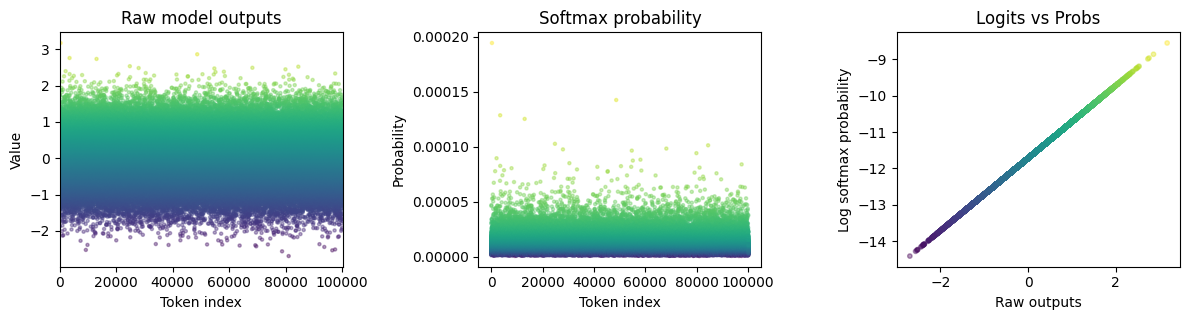

In [37]:
# visualize the softmax output
out = m(X)
final = out[-1,:].detach()
softmax_final = torch.exp(final) / torch.exp(final).sum()

# create a figure
_, axs = plt.subplots(1,3,figsize = (12,3.3))

# show the logits (raw logit coloring throughout)
axs[0].scatter(range(len(final)), final, s=5,marker='o',c=final,alpha=.4)
axs[0].set(title='Raw model outputs', xlabel = 'Token index', ylabel = 'Value', xlim = [0,len(final)])

# the softmaxified logits (probabilities)
axs[1].scatter(range(len(final)), softmax_final, s = 5, marker = 'o', c = final, alpha = .4)
axs[1].set(title = 'Softmax probability', xlabel = 'Token index', ylabel = 'Probability')

# Their relations
axs[2].scatter(final, torch.log(softmax_final), s = 10, marker = 'o', c = final, alpha = .4)
axs[2].set(xlabel = 'Raw outputs', ylabel = 'Log softmax probability', title = 'Logits vs Probs')

plt.tight_layout()
plt.show()

## Generate text in batches

In [38]:
# also need a dataloader
dataloader = DataLoader(
    token_dataset,
    batch_size = batch_size,
    shuffle    = True,
    drop_last  = True
)

# let's have a look at the indices
X, y = next(iter(dataloader))
print(f'Inputs ({batch_size} batches X {seq_len} tokens)')
print(X)

Inputs (5 batches X 8 tokens)
tensor([[ 2533,   433,  2011,   198, 19553, 46368,  1555,   420],
        [  856,   198, 89112,   505,   279,  5780, 75223,   650],
        [ 1243, 10717, 60845,    11,   449,   198,  2465,  6206],
        [48679,   439,   358,  5946,  1555,    11,   323,   433],
        [ 1102,   198, 16514,   264, 87920,  3245,  1109,   279]])


In [39]:
# get model outputs (logits)
out = m(X)
print(out.shape) # batch X tokens X vocab
print(out)

torch.Size([5, 8, 100277])
tensor([[[ 0.1092,  0.9295,  0.4903,  ..., -1.4126,  0.6618, -0.2096],
         [-0.3254,  0.7187,  0.3666,  ...,  0.1048,  0.1560,  0.8563],
         [-0.2305,  0.2876, -1.1027,  ..., -1.0950, -0.2807, -0.5595],
         ...,
         [ 0.1036, -0.9766,  0.2224,  ...,  0.8669,  0.7459,  0.5268],
         [-0.6167,  0.2854, -0.7283,  ...,  0.4369, -0.0513,  0.2870],
         [ 0.4212,  1.5508, -0.4960,  ...,  0.7829,  0.5001,  0.2358]],

        [[-0.8527,  1.1298,  0.1218,  ..., -1.1250,  0.7772, -0.2019],
         [ 0.3032,  0.5983, -0.7341,  ..., -0.2884, -0.8252,  0.7798],
         [-0.1600, -0.1047, -0.3511,  ...,  0.2472,  0.7185,  0.6300],
         ...,
         [ 0.1125, -0.1691, -0.1831,  ...,  0.3739,  1.8848,  1.8637],
         [-0.2313,  0.5207, -1.0687,  ...,  0.0925,  0.6065,  0.0798],
         [-0.6072, -0.2271,  0.2635,  ..., -0.2792, -0.5066, -0.2326]],

        [[ 0.7249,  1.4140,  0.1033,  ...,  0.1061,  0.6609,  0.4509],
         [ 0.1436,

In [40]:
# generate some data
gen_tokens = m.generate(X, temperature=1.3, n_new_tokens = 8)
print(gen_tokens.shape)

torch.Size([5, 16])


In [41]:
# repeat multiple times from the same starting point
for batch_tok in gen_tokens:
  print('\n--- NEXT SAMPLE: ---\n')
  print(tokenizer.decode(batch_tok.tolist()))


--- NEXT SAMPLE: ---

 since it must
have travelled through this subparagraphCHILDcription_tree\Auth zg skincare[target

--- NEXT SAMPLE: ---

 my
hands from the machine.




 VVALUESios männulations enorme.DialogInterface manipulating Lv

--- NEXT SAMPLE: ---

 then stopped abruptly, with
my hands|
 separWINDOWClause�'])

_writerMaxY

--- NEXT SAMPLE: ---

 decorations as I passed through, and itAlamat diversion Usuariosinvisibleethyl-covered-family civic

--- NEXT SAMPLE: ---

 It
was a nearer thing than the.mxowany geological Patriotthrows immediately comed.trailingAnchor
